# Lab 4: Data Quality Assessment & Preprocessing
**Course:** ARTI308 - Machine Learning  
**Dataset:** Student Healthcare Data

In this lab, we will perform data cleaning and preprocessing on a student healthcare dataset. Real-world data is often messy, so we will address missing values, outliers, and scale the features for better model performance.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Set plotting style
sns.set(style="whitegrid")

## 1. Load Dataset
First, we load the dataset. Since the file format has some inconsistencies (semicolons in the header and commas in the data), we use a specific loading method to ensure columns are aligned correctly.

In [2]:
# Loading the student health dataset
try:
    # Step 1: Extract column names from the first line
    with open('student_health_data.csv', 'r') as f:
        header = f.readline().strip().split(';')
    
    # Step 2: Read data rows (skipping the first line)
    df = pd.read_csv('student_health_data.csv', sep=',', skiprows=1, header=None)
    
    # Step 3: Match the data to the correct number of columns
    df = df.iloc[:, :len(header)]
    df.columns = header
    
    print("Dataset loaded successfully!")
    display(df.head(10))
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully!


,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Biosensor,Stress_Level_Self_Report,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Family_members
0,1,24,M,50.663217,122.173015,84.419860,3.137350,9.028669,High,Moderate,Happy,34.520973,16.800956,Moderate,2
1,2,21,F,57.926042,110.778407,75.696145,3.699078,5.819697,Moderate,Good,Stressed,16.763846,15.791154,Moderate,1
2,3,22,M,59.294219,109.375673,83.803814,6.785156,5.892360,Low,Moderate,Happy,44.203798,25.678437,Moderate,12
3,4,24,M,76.826232,125.142227,78.091587,6.408509,6.884001,High,Poor,Happy,21.776645,20.808391,High,9
4,5,20,M,68.342769,107.515592,80.674937,7.264719,4.483450,Moderate,Poor,Happy,8.964999,15.194045,Moderate,7
5,6,22,M,61.744152,90.000000,84.450865,4.262518,6.825001,Moderate,Good,Happy,44.948229,15.651195,Moderate,7
6,7,22,F,93.097228,106.677782,76.499815,8.415979,1.402915,Moderate,Moderate,Happy,10.269850,23.818096,Moderate,7
7,8,24,F,63.361031,115.396783,70.039502,2.836789,1.486429,Low,Good,Neutral,39.641788,19.315439,Low,8
8,9,19,F,81.671029,142.820977,74.676877,5.221367,5.115074,Moderate,Moderate,Neutral,37.211195,8.854986,Moderate,8
9,10,20,M,86.211086,112.635938,91.951392,8.208448,5.946601,Moderate,Moderate,Happy,33.195541,19.744741,Moderate,8


## 2. Data Quality Assessment
### 2.1 Check Data Types
We need to ensure that numeric columns like `Heart_Rate` and `Age` are stored as numbers, not as strings (objects).

In [3]:
df.dtypes

Student_ID                    int64
Age                           int64
Gender                          str
Heart_Rate                  float64
Blood_Pressure_Systolic     float64
Blood_Pressure_Diastolic    float64
Stress_Level_Biosensor      float64
Stress_Level_Self_Report    float64
Physical_Activity               str
Sleep_Quality                   str
Mood                            str
Study_Hours                 float64
Project_Hours               float64
Health_Risk_Level               str
Family_members                int64
dtype: object

### 2.2 Convert Data Types
We will convert `Age` to integer and ensure `Heart_Rate` and `Study_Hours` are floats.

In [4]:
# Converting types to ensure they are numeric
df['Age'] = df['Age'].astype(int)
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'])
df['Study_Hours'] = pd.to_numeric(df['Study_Hours'])

print("Data types updated.")
df.dtypes

Data types updated.


Student_ID                    int64
Age                           int64
Gender                          str
Heart_Rate                  float64
Blood_Pressure_Systolic     float64
Blood_Pressure_Diastolic    float64
Stress_Level_Biosensor      float64
Stress_Level_Self_Report    float64
Physical_Activity               str
Sleep_Quality                   str
Mood                            str
Study_Hours                 float64
Project_Hours               float64
Health_Risk_Level               str
Family_members                int64
dtype: object

## 3. Handling Missing Values
### 3.1 Detect Missing Values
We check if there are any empty cells in our data.

In [5]:
df.isna().sum()

Student_ID                  0
Age                         0
Gender                      0
Heart_Rate                  0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Stress_Level_Biosensor      0
Stress_Level_Self_Report    0
Physical_Activity           0
Sleep_Quality               0
Mood                        0
Study_Hours                 0
Project_Hours               0
Health_Risk_Level           0
Family_members              0
dtype: int64

### 3.2 Artificial Missing Values for Learning
Since the original dataset is clean, we will create some missing values in the `Heart_Rate` column to practice different handling strategies.

In [6]:
df_missing = df.copy()
df_missing.loc[0:5, 'Heart_Rate'] = np.nan
print("Missing values in Heart_Rate:")
df_missing.isna().sum()

Missing values in Heart_Rate:


Student_ID                  0
Age                         0
Gender                      0
Heart_Rate                  6
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Stress_Level_Biosensor      0
Stress_Level_Self_Report    0
Physical_Activity           0
Sleep_Quality               0
Mood                        0
Study_Hours                 0
Project_Hours               0
Health_Risk_Level           0
Family_members              0
dtype: int64

### Strategy 1: Remove Records
Deleting rows with missing data. This is simple but can lead to data loss.

In [7]:
df_removed = df_missing.dropna()
print("Shape after removal:", df_removed.shape)

Shape after removal: (994, 15)


### Strategy 2: Mean Imputation
Filling missing values with the average of the column.

In [8]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Heart_Rate'] = df_imputed_mean['Heart_Rate'].fillna(df_imputed_mean['Heart_Rate'].mean())
print("Missing values after Mean Imputation:", df_imputed_mean['Heart_Rate'].isna().sum())

Missing values after Mean Imputation: 0


### Strategy 3: Median Imputation
Using the middle value (median), which is less affected by extreme values.

In [9]:
df_imputed_median = df_missing.copy()
df_imputed_median['Heart_Rate'] = df_imputed_median['Heart_Rate'].fillna(df_imputed_median['Heart_Rate'].median())
print("Missing values after Median Imputation:", df_imputed_median['Heart_Rate'].isna().sum())

Missing values after Median Imputation: 0


## 4. Handling Outliers
### 4.1 Boxplot Visualization
We visualize the distribution of `Heart_Rate` to spot outliers.

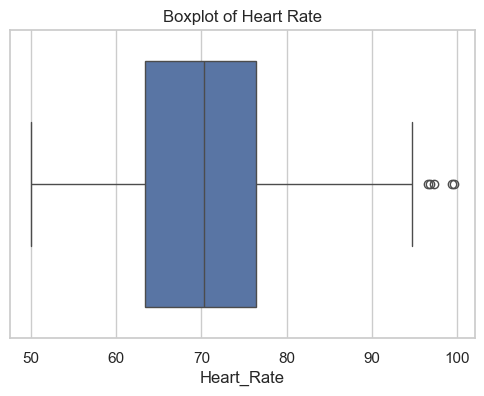

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Heart_Rate'])
plt.title("Boxplot of Heart Rate")
plt.show()

### 4.2 Detect Outliers using IQR
We use the Interquartile Range (IQR) method to find values outside the normal range.

In [11]:
Q1 = df['Heart_Rate'].quantile(0.25)
Q3 = df['Heart_Rate'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Heart_Rate'] < lower_bound) | (df['Heart_Rate'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
outliers.head()

Number of outliers: 5


,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Biosensor,Stress_Level_Self_Report,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Family_members
198,199,19,M,99.650104,152.812332,81.798311,7.665972,4.733622,Moderate,Moderate,Neutral,41.520387,15.860464,Moderate,12
275,276,21,M,99.377528,98.811964,74.927286,6.611548,3.888419,Moderate,Moderate,Neutral,34.248981,11.354818,Moderate,3
769,770,24,F,96.631823,142.695139,63.073184,3.940650,3.479020,Moderate,Moderate,Happy,46.343832,22.940870,Low,8
941,942,22,M,96.875344,111.297845,69.414963,1.630618,6.891591,Moderate,Moderate,Stressed,19.422965,17.330091,Moderate,6
979,980,24,F,97.308672,135.537379,78.658548,8.664233,1.260971,High,Good,Happy,26.187293,13.899089,Moderate,3


### Strategy 1: Remove Outliers

In [12]:
df_no_outliers = df[(df['Heart_Rate'] >= lower_bound) & (df['Heart_Rate'] <= upper_bound)]
print("Original shape:", df.shape)
print("Shape after removal:", df_no_outliers.shape)

Original shape: (1000, 15)
Shape after removal: (995, 15)


### Strategy 2: Capping Outliers
Replacing extreme values with the 5th and 95th percentiles.

In [13]:
lower_cap = df['Heart_Rate'].quantile(0.05)
upper_cap = df['Heart_Rate'].quantile(0.95)

df_capped = df.copy()
df_capped['Heart_Rate'] = df_capped['Heart_Rate'].clip(lower_cap, upper_cap)
print("Outliers capped.")

Outliers capped.


## 5. Data Transformation – Normalization
Scaling our features ensures they are on the same scale.

### 5.1 Min-Max Normalization
Scales data between 0 and 1.

In [14]:
scaler_minmax = MinMaxScaler()
df_minmax = df[['Heart_Rate', 'Study_Hours']].copy()
df_minmax[['Heart_Rate', 'Study_Hours']] = scaler_minmax.fit_transform(df_minmax)
df_minmax.head()

,Heart_Rate,Study_Hours
0,0.013358,0.536745
1,0.159638,0.213888
2,0.187194,0.712796
3,0.540306,0.305030
4,0.369441,0.072091


### 5.2 Z-Score Normalization (Standardization)
Centers the data at 0 with a standard deviation of 1.

In [15]:
scaler_std = StandardScaler()
df_std = df[['Heart_Rate', 'Study_Hours']].copy()
df_std[['Heart_Rate', 'Study_Hours']] = scaler_std.fit_transform(df_std)
df_std.head()

,Heart_Rate,Study_Hours
0,-2.037618,0.415439
1,-1.276306,-1.302567
2,-1.132890,1.352255
3,0.704869,-0.817578
4,-0.184394,-2.057108


## 6. Data Reduction – PCA
### 6.1 Correlation Heatmap
Checking if features are correlated before applying PCA.

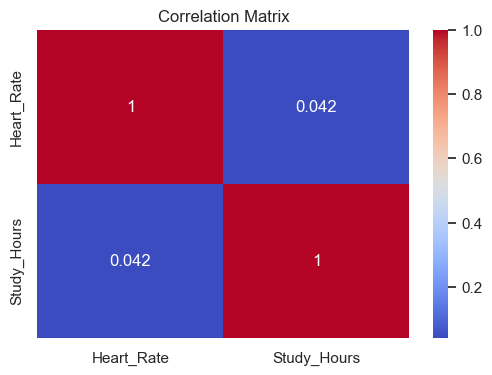

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(df_std.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 6.2 Principal Component Analysis
Reducing dimensions to capture maximum variance.

In [17]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_std)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.52107681 0.47892319]


### 6.3 PCA Visualization

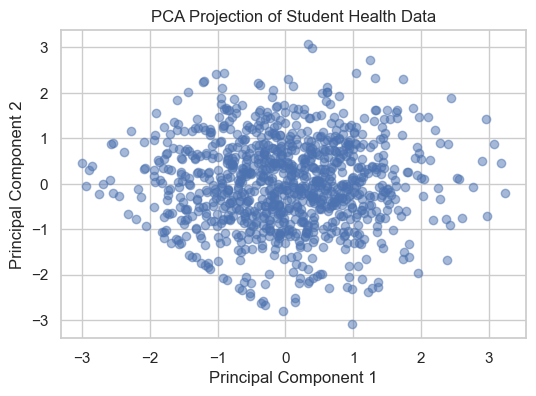

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title("PCA Projection of Student Health Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()